In [2]:
# Cell 1: Imports and setup
import os
from dotenv import load_dotenv
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv("../.env")
API_KEY = os.getenv("APCA_API_KEY_ID")
SECRET_KEY = os.getenv("APCA_API_SECRET_KEY")

In [3]:
# Cell 2: Fetch data
client = StockHistoricalDataClient(API_KEY, SECRET_KEY)

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=180)

request_params = StockBarsRequest(
    symbol_or_symbols=["AAPL"],  # requesting only one symbol
    timeframe=TimeFrame.Day,
    start=start_date,
    end=end_date
)

bars = client.get_stock_bars(request_params).df

data = bars.copy()

# Fix the MultiIndex (symbol, timestamp) to just timestamp
data = data.reset_index()  # Flattens the index so 'timestamp' becomes a column
data = data[data['symbol'] == 'AAPL']  # Filter for AAPL if multiple symbols
data = data.set_index('timestamp')     # Set datetime as index

# Ensure proper dtypes
data = data.sort_index()
data['close'] = data['close'].astype(float)

In [4]:
# Cell 3: Calculate RSI
delta = data['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

window = 14
avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()
epsilon = 1e-10
rs = avg_gain / (avg_loss + epsilon)
data['RSI'] = 100 - (100 / (1 + rs))

In [5]:
# Cell 4: Set up signals
data['position'] = 0  # 0 = no position, 1 = long

for i in range(1, len(data)):
    if data['RSI'].iloc[i-1] < 30 and data['RSI'].iloc[i] > 30:
        data.loc[data.index[i], 'position'] = 1  # Buy
    elif data['RSI'].iloc[i-1] > 70 and data['RSI'].iloc[i] < 70:
        data.loc[data.index[i], 'position'] = 0  # Sell
    else:
        data.loc[data.index[i], 'position'] = data.loc[data.index[i-1], 'position']  # Hold

In [8]:
# Cell 5: Portfolio set up
initial_cash = 10000
data['cash'] = initial_cash
data['holdings'] = 0.0
data['total'] = initial_cash
data['trade'] = 0  # 1 for buy, -1 for sell, 0 for hold

In [10]:
# Cell 6: Simulate trading
position = 0  # 0 = no position, 1 = holding
cash = initial_cash
shares = 0
data['cash'] = 0.0
data['total'] = 0.0

for i in range(1, len(data)):
    price = data['close'].iloc[i]
    
    if data['position'].iloc[i] == 1 and position == 0:
        # BUY
        shares = cash // price
        cash -= shares * price
        position = 1
        data.loc[data.index[i], 'trade'] = 1
    
    elif data['position'].iloc[i] == 0 and position == 1:
        # SELL
        cash += shares * price
        shares = 0
        position = 0
        data.loc[data.index[i], 'trade'] = -1
    
    # Update equity
    data.loc[data.index[i], 'cash'] = cash
    data.loc[data.index[i], 'holdings'] = shares * price
    data.loc[data.index[i], 'total'] = cash + (shares * price)

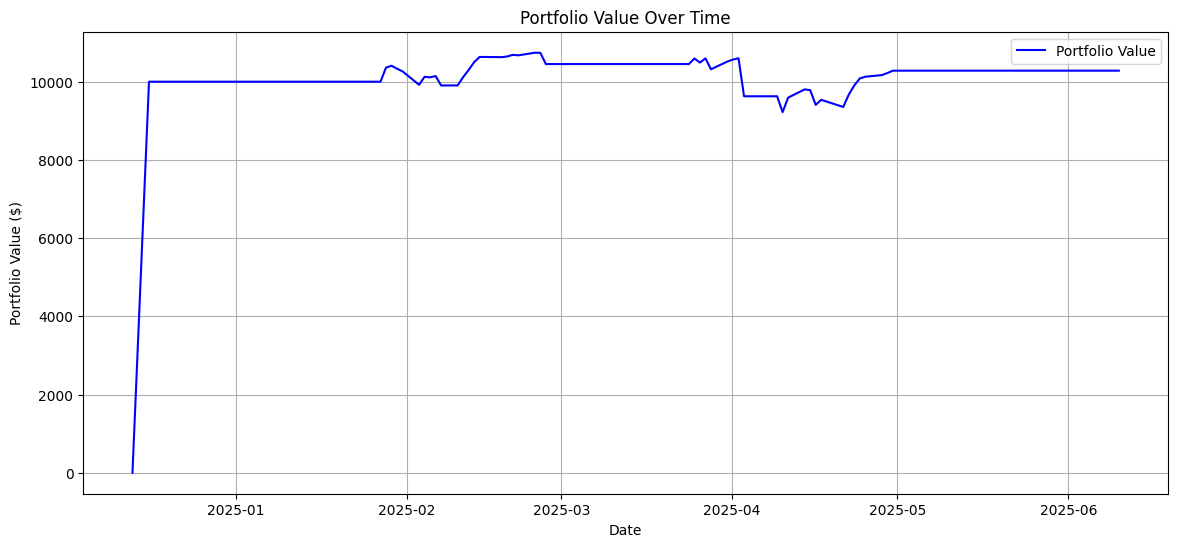

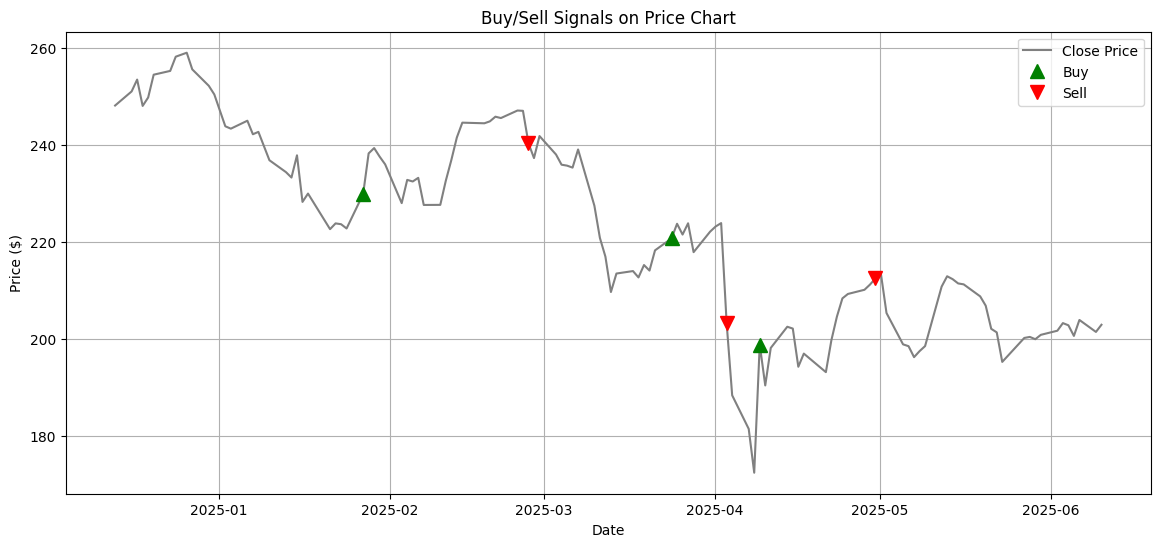

In [12]:
# Cell 7: Plot results

# Portfolio vs time
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(data.index, data['total'], label='Portfolio Value', color='blue')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.title('Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()

# Buy/sell points
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['close'], label='Close Price', color='gray')

# Buy signals
buy_signals = (data['position'].shift(1) == 0) & (data['position'] == 1)
plt.plot(data.index[buy_signals], data['close'][buy_signals], '^', color='green', markersize=10, label='Buy')

# Sell signals
sell_signals = (data['position'].shift(1) == 1) & (data['position'] == 0)
plt.plot(data.index[sell_signals], data['close'][sell_signals], 'v', color='red', markersize=10, label='Sell')

plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.title('Buy/Sell Signals on Price Chart')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Save the DataFrame to a CSV
data.to_csv("rsi_data.csv")